# Project 4 Live Recitation

Topics covered: \\
* Sigmoid Function
* Other Activatin Functions
* Class Imbalance
* Loan Default Prediction
* ROC curve

## Imports

In [ ]:
# Data Wrangling
import pandas as pd
import numpy as np

# Statistics
import statsmodels.formula.api as smf
import statsmodels.api as sm

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

# Plotting
import matplotlib.pyplot as plt

from IPython.display import Image

%matplotlib inline

#Properties of the Sigmoid

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

## Maps real values to probabilities 




plt.scatter(x,y, c = 'b')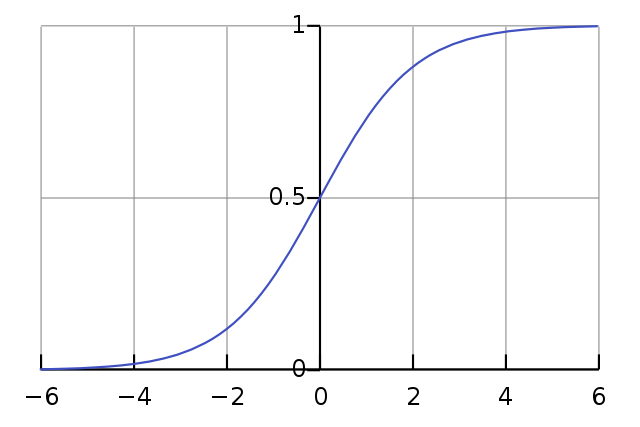

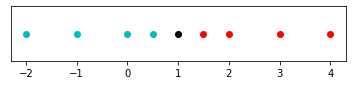

In [ ]:
# 1-D example 

plt.figure(figsize = (6,1))
x = [-2,-1,0, 0.5]
y = [0,0,0,0]
plt.scatter(x,y, c = 'c', label = 'Class 0')

x = [1.5,2,3,4]
y = [0,0,0,0]
plt.scatter(x,y, c = 'r', label = 'Class 1')
plt.scatter(1,0,c = 'k', label = 'Decision Boundary')
plt.yticks([])
plt.show()

* In the problem above, the classification function can be written as:

                  If, x - 1 > 0 , x belongs to class 1
                  If, x - 1 < 0 , x belongs to class 0

* Mapping it to probability:
  
  $ P(x \hspace{2pt} \epsilon \hspace{2pt} class1) = \sigma(x - 1) $

  Intuitively, as we go away from the decision boundary we are more confident that the datapoint belongs to a certain class 

  For x = 1, $\sigma(x-1) = \sigma(0) = 0.5$ which means on decision boundary, the point can belong to either class with equal probability

## Differentiability

$$
\begin{aligned}
\frac{d}{d x} \sigma(x) &=\frac{d}{d x}\left[\frac{1}{1+e^{-x}}\right] \\
&=\frac{d}{d x}\left(1+\mathrm{e}^{-x}\right)^{-1} \\
&=-\left(1+e^{-x}\right)^{-2}\left(-e^{-x}\right) \\
&=\frac{e^{-x}}{\left(1+e^{-x}\right)^{2}} \\
&=\frac{1}{1+e^{-x}} \cdot \frac{e^{-x}}{1+e^{-x}} \\
&=\frac{1}{1+e^{-x}} \cdot \frac{\left(1+e^{-x}\right)-1}{1+e^{-x}} \\
&=\frac{1}{1+e^{-x}} \cdot\left(\frac{1+e^{-x}}{1+e^{-x}}-\frac{1}{1+e^{-x}}\right) \\
&=\frac{1}{1+e^{-x}} \cdot\left(1-\frac{1}{1+e^{-x}}\right) \\
&=\sigma(x) \cdot(1-\sigma(x)) \\
&=\sigma(x) \cdot\sigma(-x)
\end{aligned}
$$

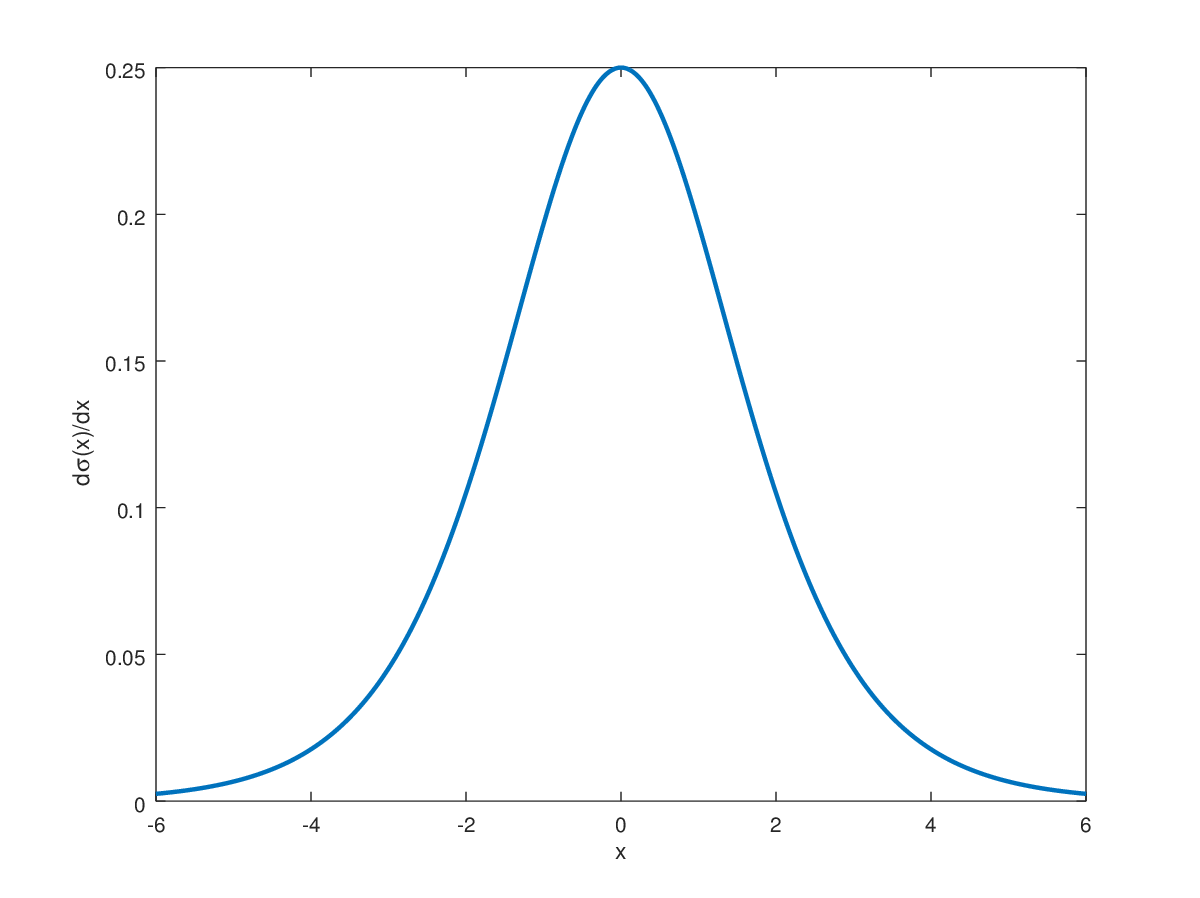


Critically important to do back-propogation for neural networks!



## Other Activation Functions

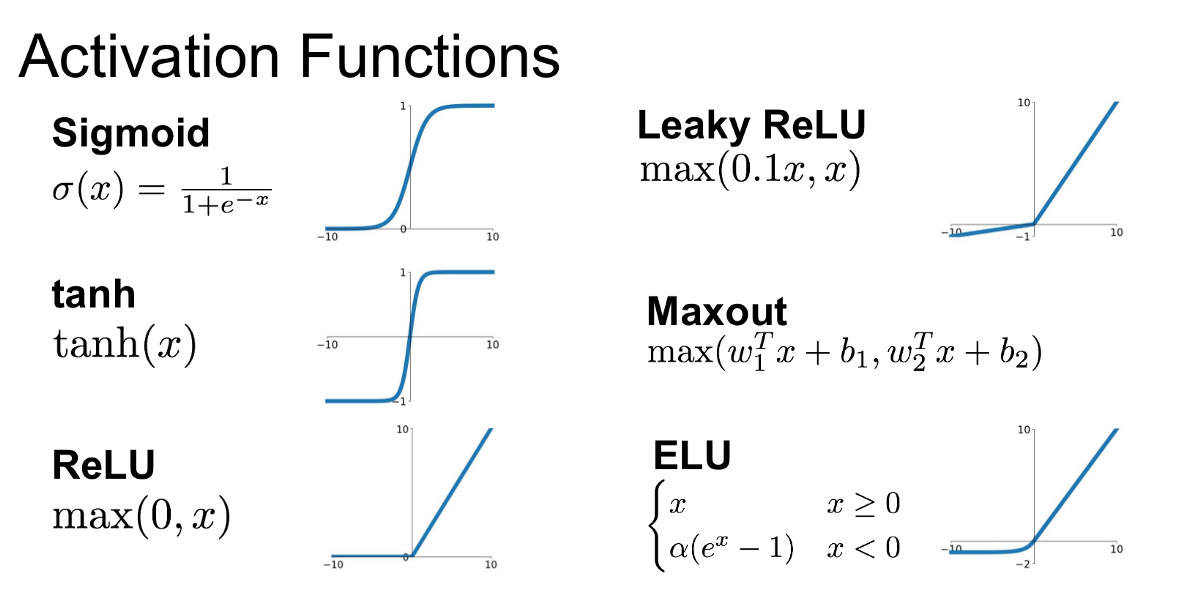

Why do people sometimes use alternatives when training neural networks?


*   Vanishing Gradient
 - With very large or very small inputs, the derivative becomes quite close to 0. Neural networks have trouble handling these small derivatives.
*   Sparsity
  - ReLu induces sparsity by setting all -ve values to 0. Furthermore, it has a constant gradient for +ve values and is much simpler to implement.



# Class Imbalance

### Slight vs. Severe Imbalance

*   Slight - Ratio of one class to another ~ 4:6
 - Typically not a concern
*   Severe - 1:4 ~ 1:100, but can encounter ratios up to 1:1000 to 1:5000
  - Most approaches to combat imabalance focus on cases up to 1:100








Was our Project 4 data imbalanced?

In [ ]:
weekly = pd.read_csv("Weekly.csv")
weekly['Direction'].value_counts(ascending=True)

Down    484
Up      605
Name: Direction, dtype: int64

Likely not a concern, failure of our model can be attributed to other causes

### Why is imbalancing problematic?

*   Classification accuracy is often the first metric we use to evaluate our models
*   Accuracy Paradox - we find that our models showcase excellent accuracy,
but that can be attributed to underlying class distribution
 - If we have a dataset of 95 0's and 5 1's, we could classify any input as 0 and achieve 95% accuracy



### Approaches to Combat Imbalancing:


*   Resampling
 -  Add copies of instances from the minority class (oversampling)
 - Delete instances from the over-represented class (undersampling)

*   Create Synthetic Samples
 - Synthetic Minority Over-sampling Technique (SMOTE)
    - Creates artificial instances of the minority class by combining features from different minority samples
*   Try a Different Algorithm
 - Decision Trees / Random Forests perform better on imbalanced data
 - We'll learn about these in Module 9!


*   Use a different Performance Metric



### Different Performance Metrics:

Precision and Recall
 - **Precision** : punishes having lots of false positives (0's classified as 1's)
 - **Recall/True Positive Rate/ Sensitivity** : punishes having lots of false negatives (1's classified as 0's)
 
If we have a dataset of 95 0's and 5 1's, which performance metric should we use to assess how we dealt with combat imbalance?






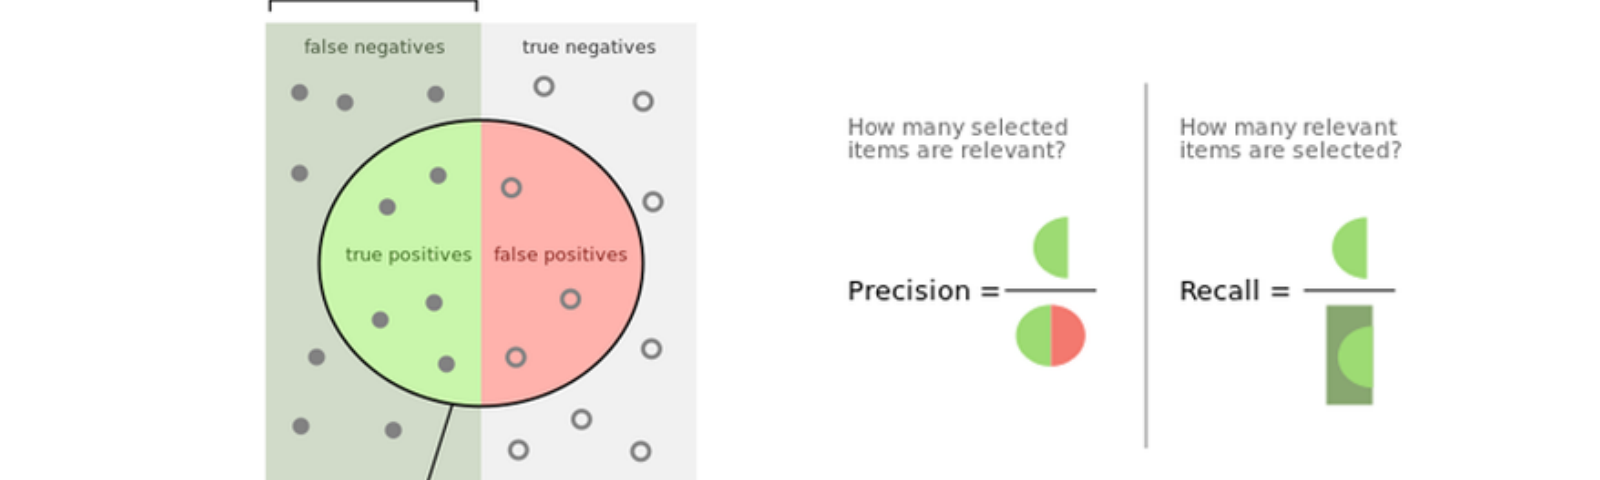


Weighted Classes:
*   We could weight 0's as having 19x the weight of 1's, so misclassification of 0's would severely harm our performance

Receiver Operating Characteristics (ROC):
*   Measures trade-off betwen TPR and FPR
*   AUC measures area under the curve, AUC = 1 is best



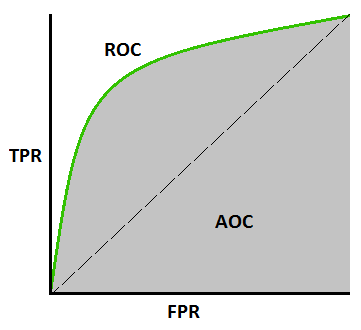

# Loan Default Prediction

Using the Default dataset from Part B of Programming Project 5

In [ ]:
default = pd.read_csv('Default.csv')
print("No. of datapoints = ", default.shape[0])
print("No. of columns = ", default.shape[1] , '\n\n')
encode = lambda x: 1 if x == 'Yes' else 0
default['default'] = default['default'].map(encode)
default['student'] = default['student'].map(encode)
default.head()

This default dataset consists of 10,000 datapoints, each with three features and an outcome (whether or not the individual defaults)


*   Default - whether or not this individual defaults on their loan
*   Student - whether or not this individual is a student
*   Balance - individual's balance at the time recorded
*   Income - individual's income at the time recorded



In [ ]:
## Let's check the number of students in the dataset

default.hist(column="student")
plt.show()

default['student'].value_counts(ascending=True)

About 30% of the dataset is comprised of students

In [ ]:
## Let's check the number of dafault instances in the dataset

default.hist(column="default")
plt.show()

default['default'].value_counts(ascending=True)

Class imbalance will need to be dealt with

### Naive approach we did in Project 4

In [ ]:
train_default, test_default = train_test_split(default, test_size = 0.2, random_state=15)

In [ ]:
naive_model = smf.glm('default~student+balance+income', data=train_default, family=sm.families.Binomial()).fit()
print(naive_model.summary())

We find that student and balance are statistically significant for this naive model

In [ ]:
pred_prob_naive_test = naive_model.predict(test_default)
predicted = [1 if p > 0.5 else 0 for p in pred_prob_naive_test]
fraction_correct_test = np.sum(predicted == test_default['default']) / len(predicted)
print("This model's accuracy on the test set is {}%".format(fraction_correct_test*100))

Our work here is done! Isn't logisitic regression wonderful?

In [ ]:
confusion_matrix(test_default['default'], predicted)

Of the 66 instances of defaulting, only 22 were caught (33.3%). This is also known as **Recall or Sensitivity or True Positive Rate (TPR)**

I think we can do better

### Approach 1 : Oversampling

In this approach, we will add in more instances from the minority class (those who default): Naive copy pasting

We can use the [imbalanced-learn library](https://imbalanced-learn.org/stable/index.html) to help with our resampling

In [ ]:
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
y_train = train_default['default']
X_train = train_default.drop(columns=['default'])

In [ ]:
ros = RandomOverSampler(random_state=0)   ##Resample all classes but the majority class
X_train_oversampled, y_train_oversampled = ros.fit_resample(X_train, y_train)   ## Get the updated dataset
X_train_oversampled_pd = pd.DataFrame(X_train_oversampled,columns=['student', 'balance', 'income'])
X_train_oversampled_pd['default'] = y_train_oversampled
X_train_oversampled_pd['default'].value_counts()

Now we have a dataset even with instances of defaulting and not defaulting!

Let's fit a new model!

In [ ]:
oversampled_model = smf.glm('default~student+balance+income', data=X_train_oversampled_pd, family=sm.families.Binomial()).fit()
print(oversampled_model.summary())

In [ ]:
pred_prob_oversampled_test = oversampled_model.predict(test_default)
predicted_os = [1 if p > 0.5 else 0 for p in pred_prob_oversampled_test]
fraction_correct_test_os = np.sum(predicted_os == test_default['default']) / len(predicted_os)
print("This model's accuracy on the test set is {}%".format(fraction_correct_test_os*100))

In [ ]:
confusion_matrix(test_default['default'], predicted_os)

Of the 66 instances of defaulting, 61 were predicted (92.4%)!

However, the **Specificity or True-Negative Rate**, has taken a hit (1671 / 1671 + 263) = 86.4%. Earlier, it was at 99.3%

### Approach 2 : Undersampling

In this approach, we randomly drop instances of not-defaulting, until the amount is comparable to the number of defaulting instances

In [ ]:
rus = RandomUnderSampler(random_state=0)             ##Resample all classes but minority class
X_train_undersampled, y_train_undersampled = rus.fit_resample(X_train, y_train)    ##Get the updated dataset
X_train_undersampled_pd = pd.DataFrame(X_train_undersampled,columns=['student', 'balance', 'income'])
X_train_undersampled_pd['default'] = y_train_undersampled
X_train_undersampled_pd['default'].value_counts()

In [ ]:
undersampled_model = smf.glm('default~student+balance+income', data=X_train_undersampled_pd, family=sm.families.Binomial()).fit()
print(undersampled_model.summary())

In this model, being a student is no longer significant. Perhaps students aren't as likely to default on loans

In [ ]:
pred_prob_undersampled_test = undersampled_model.predict(test_default)
predicted_us = [1 if p > 0.5 else 0 for p in pred_prob_undersampled_test]
fraction_correct_test_us = np.sum(predicted_us == test_default['default']) / len(predicted_us)
print("This model's accuracy on the test set is {}%".format(fraction_correct_test_us*100))

In [ ]:
confusion_matrix(test_default['default'], predicted_us)

We get the same sensitivity as the oversampled approach, but slightly worse specificity

### Sampling Methods Debrief



*   Why might oversampling be a bad approach?
*   Why might undersampling be a bad approach?
*   Which do you think is more widely used in practice? 
 - [Answer](https://qr.ae/pNB5A3)

*   When we add or remove class instances, what are we really doing? (think about class probabilities)
*   How do we decide the tradeoff between specificity vs sensitivity?





## Approach 3 : SMOTE (Synthetic Minority Oversampling Technique)

See the original [paper here](https://arxiv.org/abs/1106.1813)!

When we oversample the minority class, we even up the class distributions, but don't provide any new information to the model

SMOTE attempts to solve this by synthesizing new examples from the minority class


*   Finds two minority instances **that are close in the feature space** (perhaps both students and similar incomes)
*   Draws a line between them, and samples a new point to add to the dataset

This continues until the size of the minority class is comparable with the majority class





Curse of Dimensionality - when we have many features, how can two minority instances be close?

In [ ]:
smote = SMOTE(random_state=0)            ##Resample all classes but the majority class
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)   ## Get the updated dataset
X_train_smote_pd = pd.DataFrame(X_train_smote,columns=['student', 'balance', 'income'])
X_train_smote_pd['default'] = y_train_smote
X_train_smote_pd['default'].value_counts()

In [ ]:
smote_model = smf.glm('default~student+balance+income', data=X_train_smote_pd, family=sm.families.Binomial()).fit()
print(smote_model.summary())

In [ ]:
pred_prob_smote_test = smote_model.predict(test_default)
predicted_smote = [1 if p > 0.5 else 0 for p in pred_prob_smote_test]
fraction_correct_test_smote = np.sum(predicted_smote == test_default['default']) / len(predicted_smote)
print("This model's accuracy on the test set is {}%".format(fraction_correct_test_smote*100))

In [ ]:
confusion_matrix(test_default['default'], predicted_smote)

SMOTE's sensitivity is slightly worse than our other sampling methods above (90.9%), but shows better specificity (87.9% vs 86.4%). Given the majority of instances are non-default, this improvement is significant!

## AUC / ROC Curve

Image source and also a really great blog post: [Understanding AUC ROC Curve](https://towardsdatascience.com/understanding-auc-roc-curve-68b2303cc9c5)

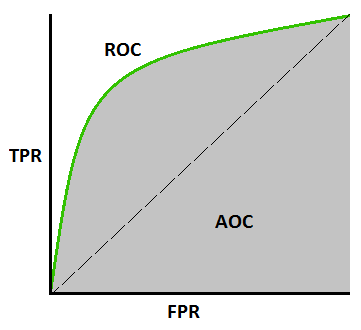

$$
\text{TPR/Sensitivity} = \frac{\text{TP}}{\text{TP+FN}}
$$
\
$$
\text{Specificity} = \frac{\text{TN}}{\text{TN+FP}}
$$
\
$$
\text{FPR} = 1 - \text{Specificity} = \frac{\text{FP}}{\text{TN+FP}}
$$

For a perfect classifier, the curve will consume the entire space and have AUC (area under curve) = 1

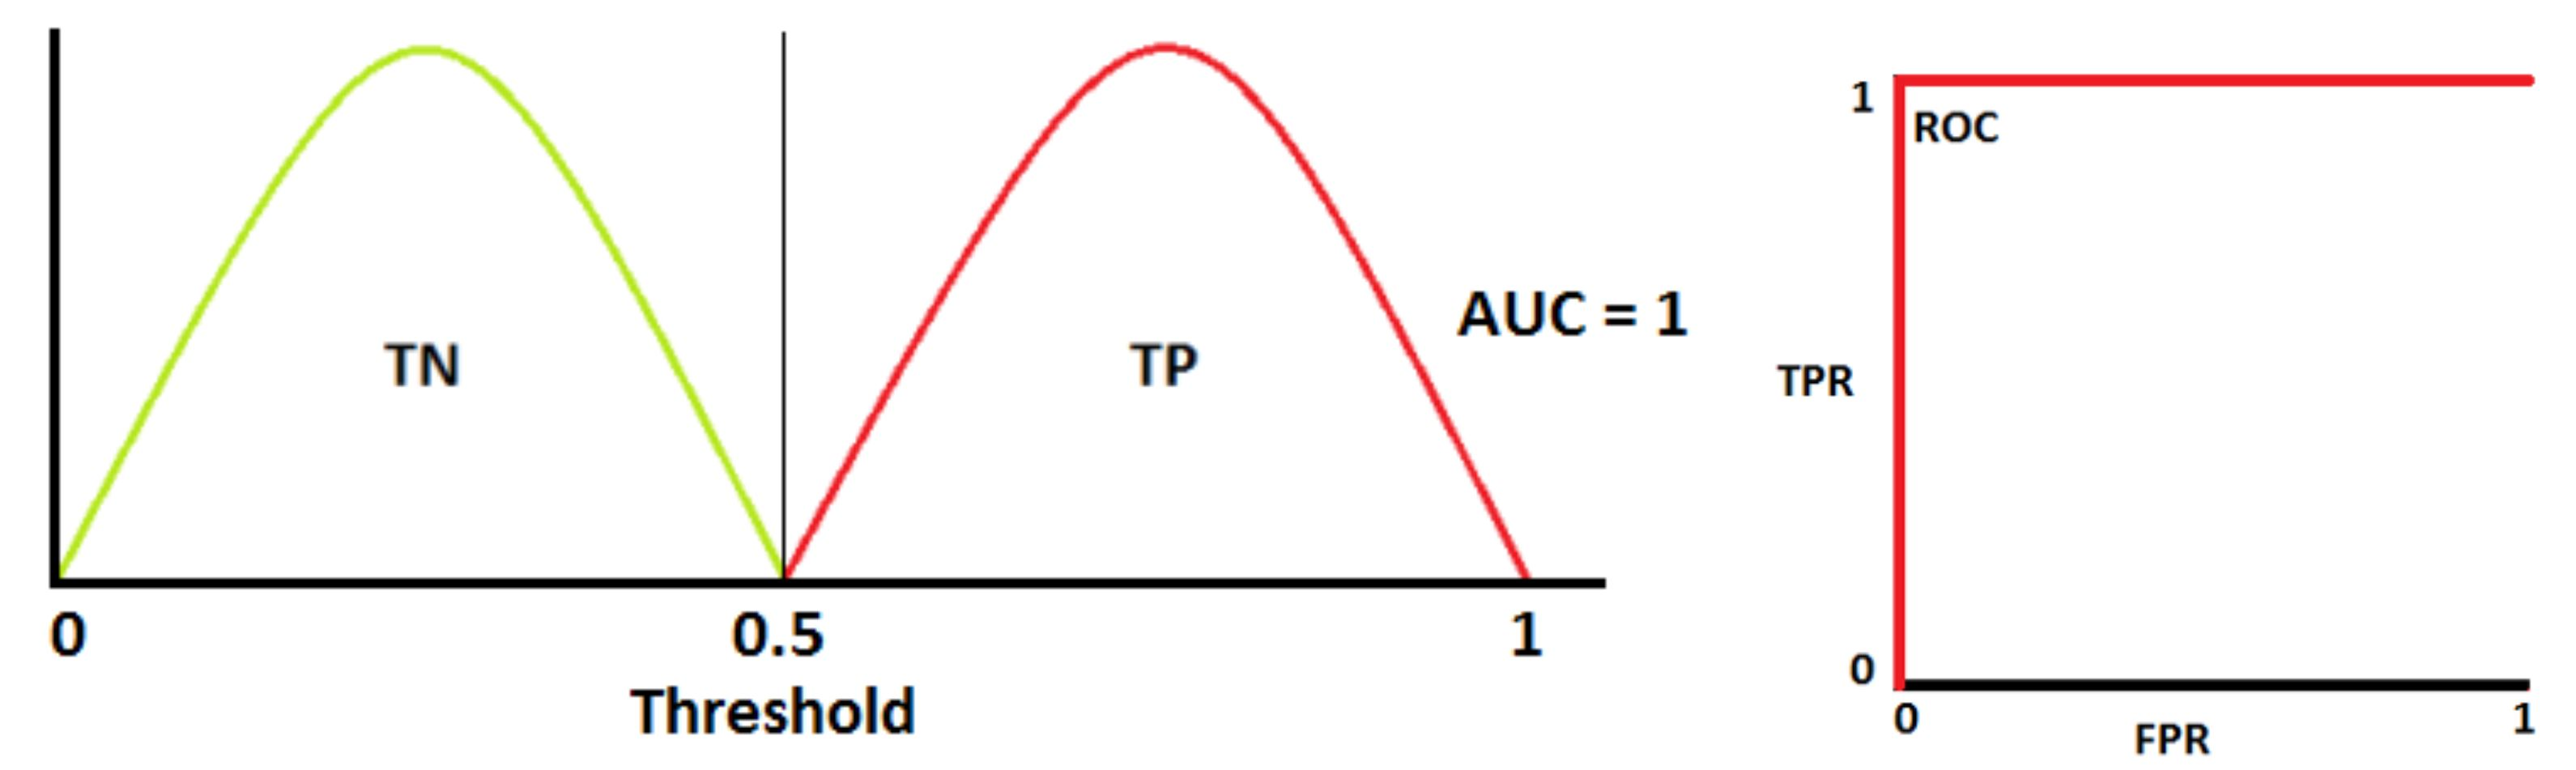

For a naive classifier, the curve will have a 50% chance of classifying an instance.

Can our classifier ever do worse than 50?

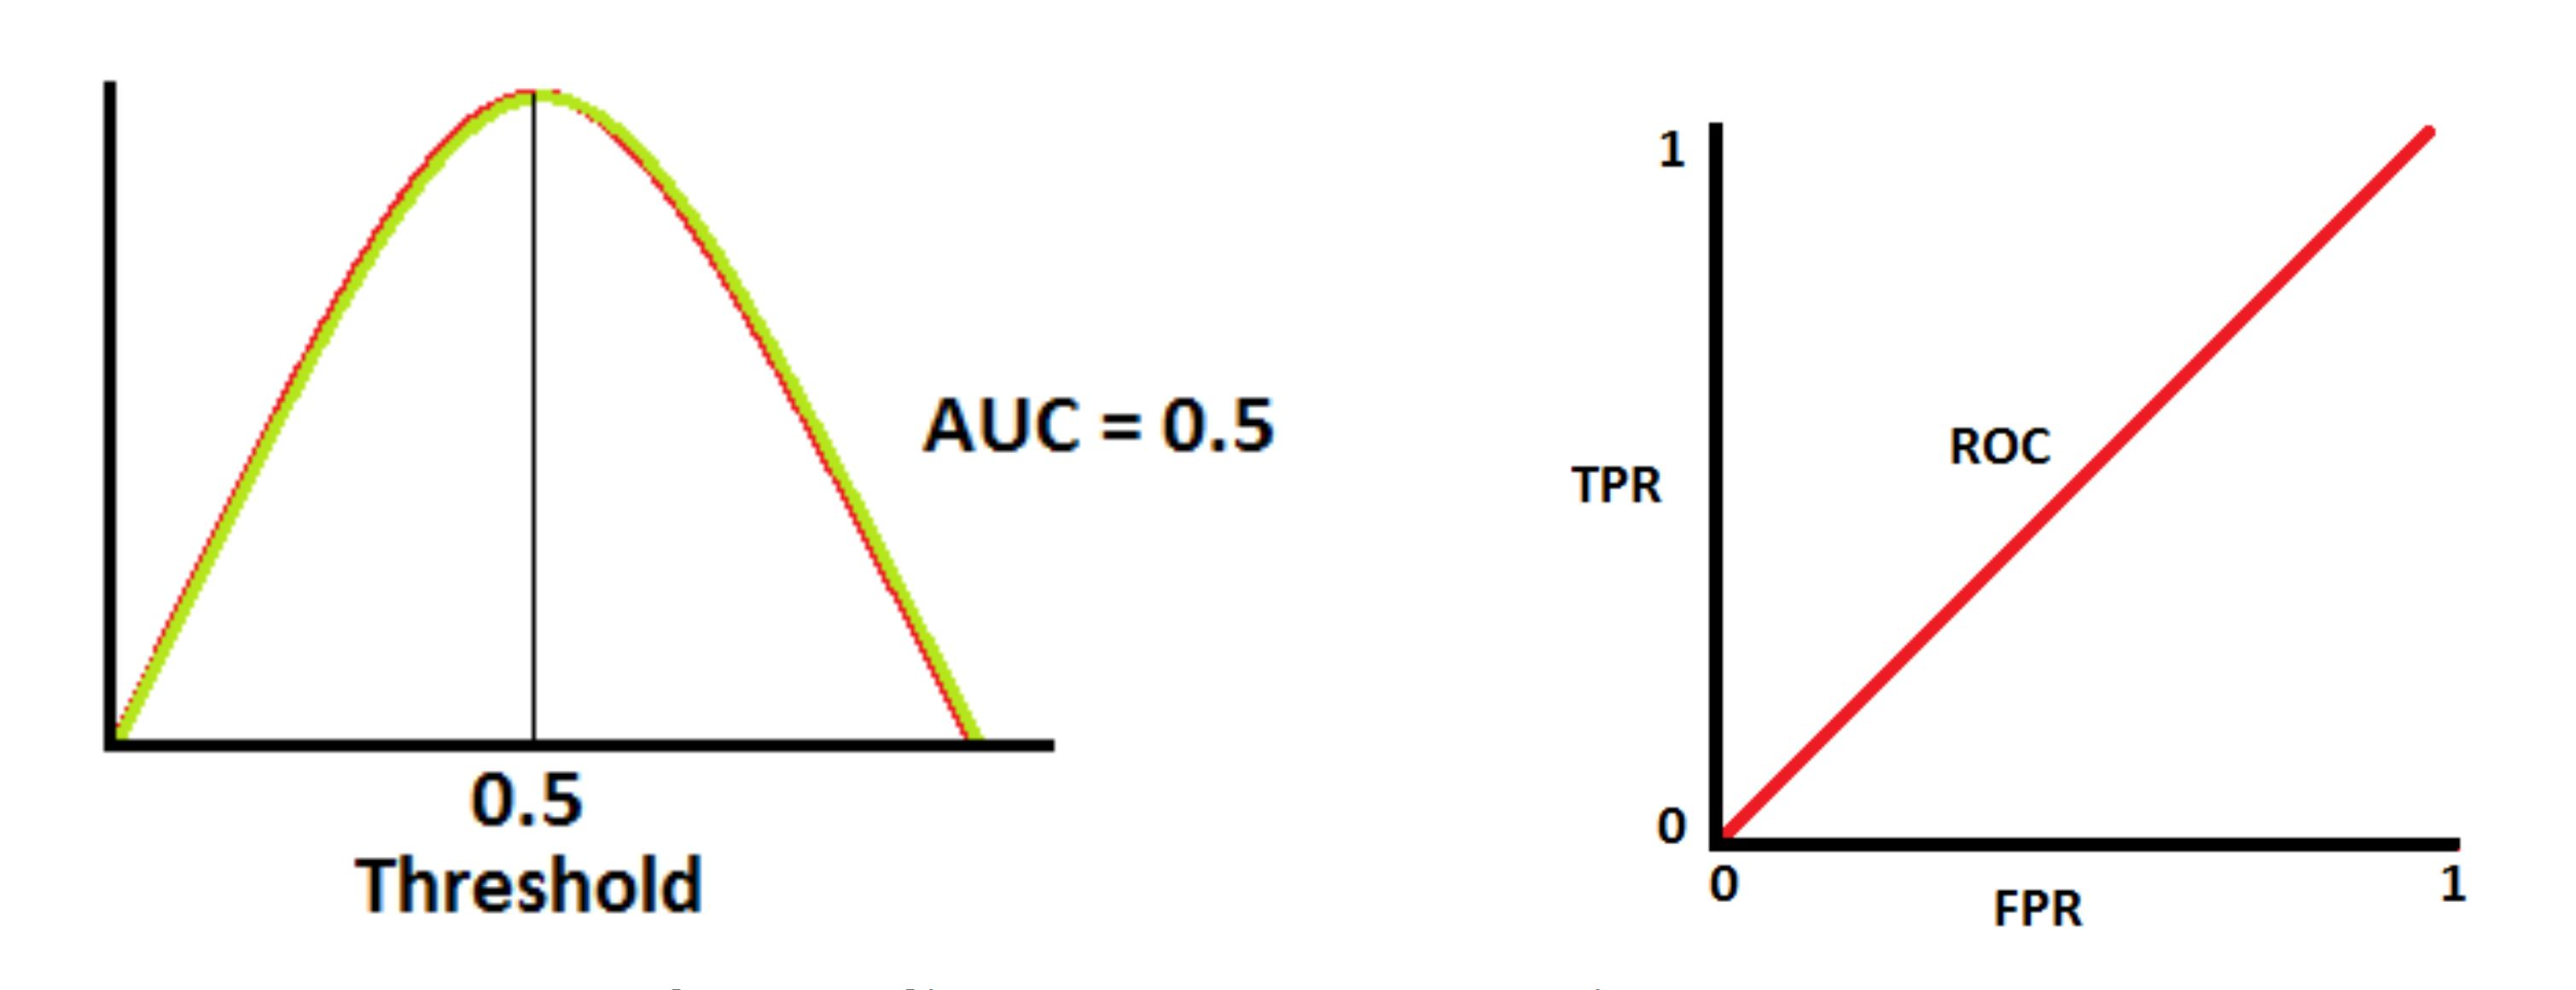

In [ ]:
import sklearn.metrics as metrics

label = test_default['default'].to_numpy()

fpr, tpr, thresh = metrics.roc_curve(label, pred_prob_naive_test.to_numpy())
auc = metrics.roc_auc_score(label, pred_prob_naive_test.to_numpy())
plt.plot(fpr,tpr,label="Naive Classifier, auc="+str(round(auc,3)))

fpr, tpr, thresh = metrics.roc_curve(label, pred_prob_oversampled_test.to_numpy())
auc = metrics.roc_auc_score(label, pred_prob_oversampled_test.to_numpy())
plt.plot(fpr,tpr,label="Oversampled Classifier, auc="+str(round(auc,3)))

fpr, tpr, thresh = metrics.roc_curve(label, pred_prob_undersampled_test.to_numpy())
auc = metrics.roc_auc_score(label, pred_prob_undersampled_test.to_numpy())
plt.plot(fpr,tpr,label="Undersampled Classifier, auc="+str(round(auc,3)))

fpr, tpr, thresh = metrics.roc_curve(label, pred_prob_smote_test.to_numpy())
auc = metrics.roc_auc_score(label, pred_prob_smote_test.to_numpy())
plt.plot(fpr,tpr,label="SMOTE Classifier, auc="+str(round(auc,3)))

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Classifier ROC Comparison")
plt.legend(loc=0)

## The Road Ahead


*    Decision Trees / Random Forests perform better on imbalanced data. We'll learn about these starting in Module 9!
*   The issue of imbalanced data is ubiquitous
 - Anomaly detection (credit card fraud, sensor event dection)
 - Search for exoplanets


